# Decision Tree

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs

In [42]:
X,y = make_blobs(n_samples=[10,15,25], centers=[[-1,-1],[0,1],[1,0]])
X,y

(array([[ 2.95797813, -1.0136602 ],
        [ 2.28176633,  1.06138633],
        [ 0.70221149,  0.81840876],
        [-1.08405271,  1.10150975],
        [ 0.58849986,  2.02460499],
        [-2.26227699, -0.75174033],
        [-1.91053623, -1.36988202],
        [-0.09104647,  1.52126085],
        [-0.16038373,  1.0693204 ],
        [ 0.01289619, -1.31187955],
        [ 0.29032382, -0.60350779],
        [-0.31249566, -1.04938155],
        [ 0.62562596,  2.19404503],
        [ 2.32550941, -1.74395595],
        [ 2.22979656, -0.86389064],
        [-2.02968559,  0.19329733],
        [ 0.65317654,  1.86722971],
        [ 0.87672767,  0.29746888],
        [ 0.20393339,  0.00974269],
        [ 1.44963847,  0.41527407],
        [-0.16338491, -0.94377886],
        [ 0.08980565,  1.31018515],
        [ 2.06828563,  0.26203779],
        [-0.99732193, -1.42029574],
        [ 1.02889613,  0.4970691 ],
        [ 2.55235901, -0.1101289 ],
        [-1.42065323, -2.1746181 ],
        [-0.20259347, -2.797

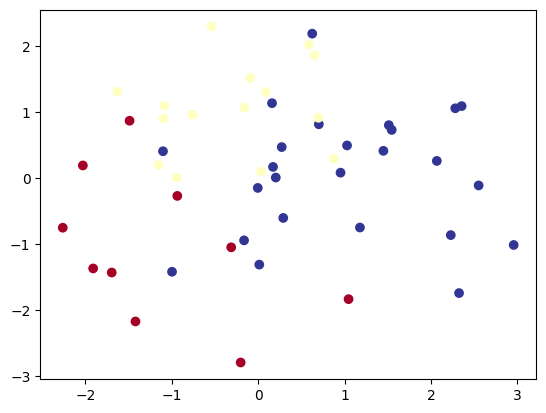

In [43]:
plt.scatter(X[:,0],X[:,1], c=y ,cmap='RdYlBu')
plt.show()

In [44]:
y

array([2, 2, 2, 1, 1, 0, 0, 1, 1, 2, 2, 0, 2, 2, 2, 0, 1, 1, 2, 2, 2, 1,
       2, 2, 2, 2, 0, 0, 1, 2, 1, 1, 0, 2, 1, 1, 2, 1, 2, 2, 1, 1, 0, 0,
       2, 0, 2, 2, 2, 2])

In [45]:
classes = np.unique(y)
classes

array([0, 1, 2])

In [46]:
y_onehot = np.array([y]).T == classes

In [47]:
probs = np.mean(y_onehot,axis=0)

In [48]:
def entropy(probs):
    return np.sum(-probs * np.log2(probs + 1e-100))

In [49]:
entropy(probs)

np.float64(1.4854752972273344)

In [50]:
entropy(np.array([0,1.0]))

np.float64(0.0)

In [57]:
def determine_split(X, y_onehot):
    """returns the best feature and best split threshold"""
    best_feature = best_threshold = None
    best_entropy = float('inf') 
    for feature in range(X.shape[1]):
        uniques = np.unique(X[:,feature])
        for index in range(len(uniques) -1):
            threshold = uniques[index] + uniques[index + 1] / 2.0
            subset_left = (X[:,feature] <= threshold)
            # subset_right = (X[:,feature] > threshold)
            subset_right = ~subset_left
            
            probs_left = np.mean(y_onehot[subset_left,:],axis=0)
            probs_right = np.mean(y_onehot[subset_right,:],axis=0)
            
            entropy_left = entropy(probs_left)
            entropy_right = entropy(probs_right)
            
            entropy_mean = np.mean(subset_left) * entropy_left \
                            +np.mean(subset_right) * entropy_right
            if entropy_mean < best_entropy:
                best_feature = feature
                best_threshold = threshold
                best_entropy = entropy_mean
                
        return best_feature, best_threshold
        
#bestfeature, bestsplitvalue,bestentroy=None

#for every feature
    # for every split point
        # compute left probabilities, entropy (Hleft)
        # compute the right probabilities, entropy (Hright)
        # take the weighted average (Hbottom)
        # if Hbottom is better than bestentropy:
            #remember best...
print(determine_split(X,y_onehot))

(0, np.float64(-0.09334354475294028))


In [58]:
# Decision stump
def fit_predict_proba(X, y, X_test):
    """trains the decision stump and predicts class probabilities for test data"""
    #Training
    classes = np.unique(y)
    y_onehot = (np.array([y]).T == classes)
    best_feature , best_threshold = determine_split(X,y_onehot)
    # prediction
    subset_left = (X[:,best_feature] <= best_threshold)
    subset_right = ~subset_left

    proba_left = np.mean(y_onehot[subset_left,:],axis = 0)
    proba_right = np.mean(y_onehot[subset_right,:],axis = 0)
    
    # subset_test_left = (X_test[:,best_feature] <= best_threshold)
    # subset_test_right = (X_test[:,best_feature] > best_threshold)
    
    y_proba = np.empty((X_test.shape[0],len(classes)))
    for instance in range(X_test.shape[0]):
        if X_test[instance,best_feature] <= best_threshold:
            # left branch
            y_proba[instance,:] = proba_left
        else:
            y_proba[instance,:] = proba_right
    
    return y_proba

In [59]:

y_proba = fit_predict_proba(X, y, X)

In [60]:
y_proba

array([[0.03333333, 0.23333333, 0.73333333],
       [0.03333333, 0.23333333, 0.73333333],
       [0.03333333, 0.23333333, 0.73333333],
       [0.45      , 0.4       , 0.15      ],
       [0.03333333, 0.23333333, 0.73333333],
       [0.45      , 0.4       , 0.15      ],
       [0.45      , 0.4       , 0.15      ],
       [0.03333333, 0.23333333, 0.73333333],
       [0.45      , 0.4       , 0.15      ],
       [0.03333333, 0.23333333, 0.73333333],
       [0.03333333, 0.23333333, 0.73333333],
       [0.45      , 0.4       , 0.15      ],
       [0.03333333, 0.23333333, 0.73333333],
       [0.03333333, 0.23333333, 0.73333333],
       [0.03333333, 0.23333333, 0.73333333],
       [0.45      , 0.4       , 0.15      ],
       [0.03333333, 0.23333333, 0.73333333],
       [0.03333333, 0.23333333, 0.73333333],
       [0.03333333, 0.23333333, 0.73333333],
       [0.03333333, 0.23333333, 0.73333333],
       [0.45      , 0.4       , 0.15      ],
       [0.03333333, 0.23333333, 0.73333333],
       [0.

In [61]:
y_hat = np.argmax(y_proba ,axis=1)
y_hat

array([2, 2, 2, 0, 2, 0, 0, 2, 0, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 0, 2,
       2, 0, 2, 2, 0, 0, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 0, 0, 0,
       2, 0, 0, 2, 2, 2])

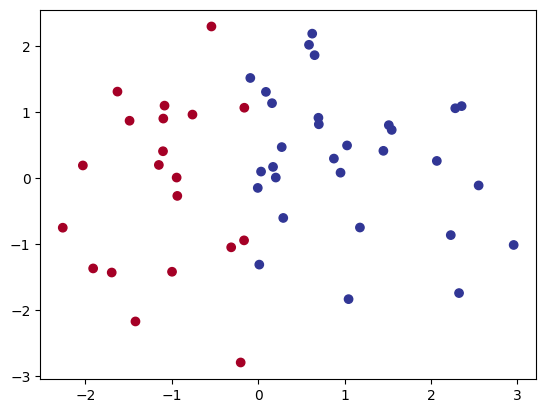

In [62]:
plt.scatter(X[:,0],X[:,1], c=y_hat ,cmap='RdYlBu')
plt.show()

In [ ]:
# decision tree
if all labels homogenous (entropy = 0) or
if depth > max_depth then 
    then return prob.distribution of the current labels in this node
determine split feature and threshold
sudivide training data in left and right branch
recursively use decision tree on left
recursively use decision tree on right
combine the predicted labels